In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

In [2]:
# 1. Carregar os dados
df = pd.read_csv("dados_manutencao.csv")

# 2. Remover colunas irrelevantes
df = df.drop(
    [
        "Data de Produção Acumulada",
        "Cod. Ordem",
        "Cod Recurso",
        "Fator Un.",
        "Cód. Un.",
        "Descrição da massa (Composto)",
    ],
    axis=1,
)

# 3. Renomear colunas
df = df.rename(
    columns={
        "Qt. Total Acumulada Produzida até a data específica": "Qtd_Produzida",
        "Qt. Acumulada Refugada até a data específica": "Qtd_Refugada",
        "Qtd. Acumulada total Retrabalhada até a data específica": "Qtd_Retrabalhada",
    }
)

# 4. Codificar one-hot as variáveis categóricas
df = pd.get_dummies(df, columns=["Cod Produto"])

# 5. Dividir os dados em conjuntos de treinamento e teste
X = df.drop("Tempo Restante para Manutenção", axis=1)
y = df["Tempo Restante para Manutenção"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6. Criar o pipeline
numeric_features = [
    "Qtd_Produzida",
    "Qtd_Refugada",
    "Qtd_Retrabalhada",
    "Consumo total de Massa Acumulada",
]
categorical_features = [
    "Cod Produto_SA02004",
    "Cod Produto_SA02961",
    "Cod Produto_SA05780",
]

numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])
categorical_transformer = Pipeline(
    steps=[("onehot", OneHotEncoder(handle_unknown="ignore"))]
)

In [3]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

pipeline = Pipeline(
    steps=[("preprocessor", preprocessor), ("regressor", RandomForestRegressor())]
)

# 7. Ajustar os hiperparâmetros do modelo
param_grid = {
    "regressor__n_estimators": [50, 100, 200],
    "regressor__max_depth": [None, 5, 10],
    "regressor__min_samples_split": [2, 5, 10],
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring="neg_mean_squared_error")
grid_search.fit(X_train, y_train)

# 8. Fazer previsões e avaliar o modelo
y_pred = grid_search.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [4]:
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

# 9. Discretizar a variável 'Tempo Restante para Manutenção'
# Definir os limites para cada categoria
bins = [
    -float("inf"),
    -200,
    -100,
    float("inf"),
]  # Ajuste os limites conforme necessário
labels = ["Curto", "Médio", "Longo"]

# Discretizar as variáveis de teste e previsão
y_test_discretized = pd.cut(y_test, bins=bins, labels=labels)
y_pred_discretized = pd.cut(y_pred, bins=bins, labels=labels)

Mean Squared Error: 11123.20
R-squared: -0.02


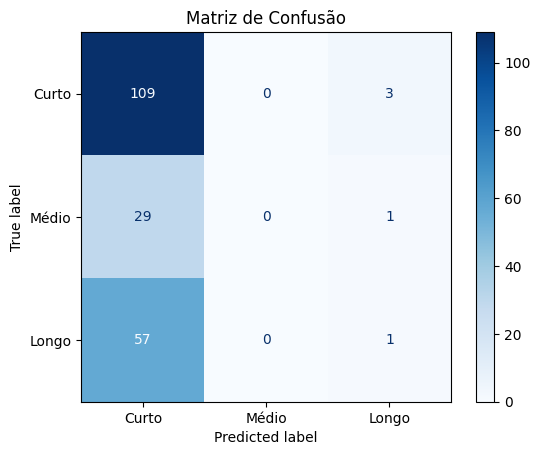

In [5]:
# 10. Calcular a matriz de confusão
cm = confusion_matrix(y_test_discretized, y_pred_discretized)

# 11. Criar o heatmap da matriz de confusão
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues")

# 12. Exibir o gráfico
plt.title("Matriz de Confusão")
plt.show()

In [6]:
# Neste código, a linha y_test_discretized = pd.cut(y_test, bins=bins, labels=labels) e y_pred_discretized = pd.cut(y_pred, bins=bins, labels=labels)  discretizam as variáveis y_test e y_pred em três categorias: "Curto", "Médio" e "Longo", com base nos limites definidos em bins. Ajuste os limites em bins de acordo com a sua necessidade.